# 🫀 Analisis Dataset CAD (Coronary Artery Disease) - Alizadeh

## Struktur Notebook
1. **Part 1 – Supervised Learning**: Klasifikasi target `Cath` (CAD vs Normal)
   - Preprocessing & Statistika Eksplorasi
   - Feature Selection & Analisis Pemilihan Atribut
   - Pembagian Data Latih & Test
   - Pemilihan & Perbandingan Metode Klasifikasi
   - Evaluasi Komprehensif

2. **Part 2 – Unsupervised Learning (K-Means from Scratch)**:
   - Pemilihan Jumlah Kluster (Elbow + Silhouette)
   - Implementasi K-Means Murni (tanpa library)
   - Analisis Kualitas Kluster

---


# PART 1 — SUPERVISED LEARNING

## 1.1 Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

# Classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Styling
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
COLORS = ['#2563EB', '#DC2626']

# Load data
df_raw = pd.read_excel('CAD_alizadeh.xls', engine='xlrd')
df = df_raw.copy()
print(f"Dataset shape: {df.shape}")
print(f"\nKolom: {df.columns.tolist()}")
print(f"\nTarget (Cath):\n{df['Cath'].value_counts()}")


Dataset shape: (303, 56)

Kolom: ['No', 'Age', 'Weight', 'Length', 'Sex', 'BMI', 'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'BP', 'PR', 'Edema', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Typical Chest Pain', 'Dyspnea', 'Function Class', 'Atypical', 'Nonanginal', 'Exertional CP', 'LowTH Ang', 'Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'LVH', 'Poor R Progression', 'FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE', 'Region RWMA', 'VHD', 'Cath']

Target (Cath):
Cath
Cad       216
Normal     87
Name: count, dtype: int64


## 1.2 Preprocessing & Statistika Eksplorasi

### 1.2.1 Informasi Dasar Dataset


In [2]:
# Info dasar
print("="*60)
print("INFORMASI DASAR DATASET")
print("="*60)
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print(f"Missing values : {df.isnull().sum().sum()}")

print("\n--- Tipe Data ---")
dtype_summary = df.dtypes.value_counts()
print(dtype_summary)

print("\n--- Distribusi Target ---")
target_counts = df['Cath'].value_counts()
for label, count in target_counts.items():
    print(f"  {label:8s}: {count:4d} ({count/len(df)*100:.1f}%)")


INFORMASI DASAR DATASET
Jumlah baris   : 303
Jumlah kolom   : 56
Missing values : 0

--- Tipe Data ---
int64      30
str        21
float64     5
Name: count, dtype: int64

--- Distribusi Target ---
  Cad     :  216 (71.3%)
  Normal  :   87 (28.7%)


### 1.2.2 Statistik Deskriptif Fitur Numerik

In [3]:
# Statistik deskriptif
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'No']
print("Statistik Deskriptif Fitur Numerik:")
display(df[num_cols].describe().round(2))


Statistik Deskriptif Fitur Numerik:


,Age,Weight,Length,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,BP,...,ESR,HB,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,...,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,58.90,73.83,164.72,27.25,0.30,0.59,0.21,0.03,0.16,129.55,...,19.46,13.15,4.23,141.00,7562.05,32.40,60.15,221.49,47.23,0.62
std,10.39,11.99,9.33,4.10,0.46,0.49,0.41,0.18,0.37,18.94,...,15.94,1.61,0.46,3.81,2413.74,9.97,10.18,60.80,8.93,1.13
min,30.00,48.00,140.00,18.12,0.00,0.00,0.00,0.00,0.00,90.00,...,1.00,8.90,3.00,128.00,3700.00,7.00,32.00,25.00,15.00,0.00
25%,51.00,65.00,158.00,24.51,0.00,0.00,0.00,0.00,0.00,120.00,...,9.00,12.20,3.90,139.00,5800.00,26.00,52.50,183.50,45.00,0.00
50%,58.00,74.00,165.00,26.78,0.00,1.00,0.00,0.00,0.00,130.00,...,15.00,13.20,4.20,141.00,7100.00,32.00,60.00,210.00,50.00,0.00
75%,66.00,81.00,171.00,29.41,1.00,1.00,0.00,0.00,0.00,140.00,...,26.00,14.20,4.50,143.00,8800.00,39.00,67.00,250.00,55.00,1.00
max,86.00,120.00,188.00,40.90,1.00,1.00,1.00,1.00,1.00,190.00,...,90.00,17.60,6.60,156.00,18000.00,60.00,89.00,742.00,60.00,4.00


### 1.2.3 Visualisasi Distribusi Target & Demografis

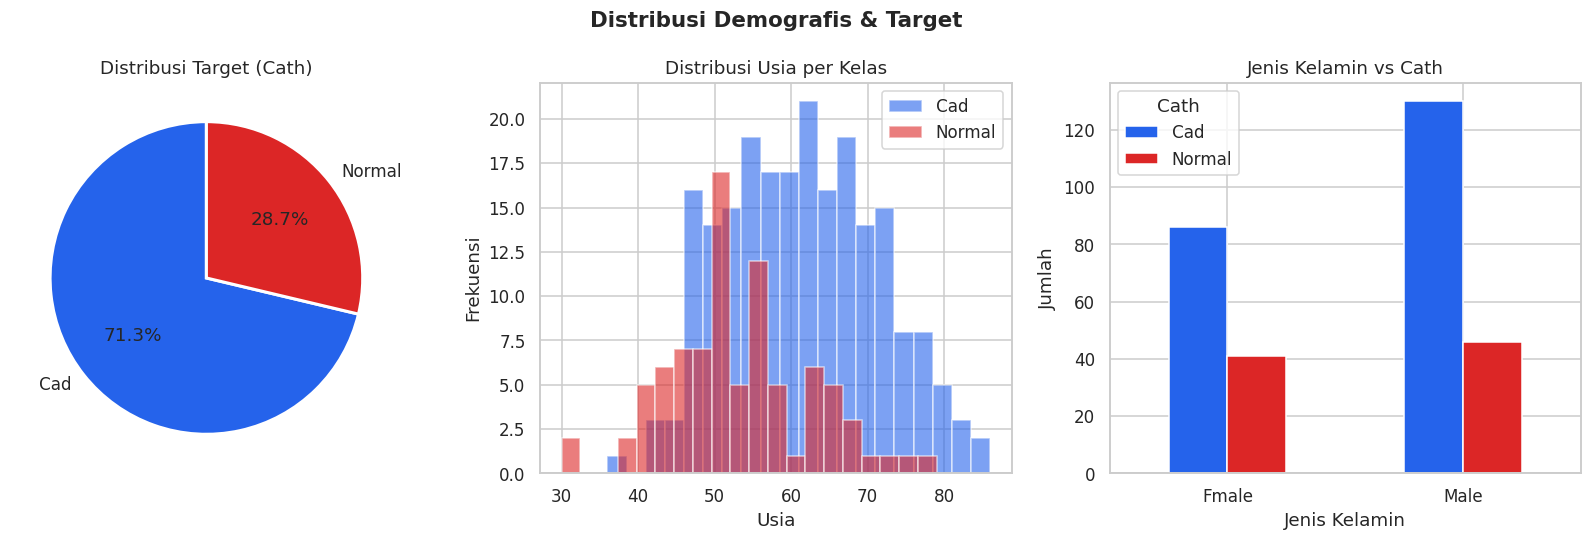


Analisis: Dataset tidak seimbang (71.3% CAD vs 28.7% Normal).
Mayoritas pasien CAD adalah laki-laki dengan usia rata-rata ~59 tahun.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Demografis & Target', fontsize=14, fontweight='bold')

# Target distribution
axes[0].pie(target_counts.values, labels=target_counts.index,
            colors=COLORS, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[0].set_title('Distribusi Target (Cath)')

# Age distribution by Cath
for i, (label, grp) in enumerate(df.groupby('Cath')['Age']):
    axes[1].hist(grp, alpha=0.6, bins=20, label=label, color=COLORS[i], edgecolor='white')
axes[1].set_xlabel('Usia')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Usia per Kelas')
axes[1].legend()

# Sex vs Cath
sex_cath = pd.crosstab(df['Sex'], df['Cath'])
sex_cath.plot(kind='bar', ax=axes[2], color=COLORS, edgecolor='white', rot=0)
axes[2].set_xlabel('Jenis Kelamin')
axes[2].set_ylabel('Jumlah')
axes[2].set_title('Jenis Kelamin vs Cath')
axes[2].legend(title='Cath')

plt.tight_layout()
plt.savefig('fig1_demo_dist.png', bbox_inches='tight')
plt.show()
print("\nAnalisis: Dataset tidak seimbang (71.3% CAD vs 28.7% Normal).")
print("Mayoritas pasien CAD adalah laki-laki dengan usia rata-rata ~59 tahun.")


### 1.2.4 Distribusi Fitur Klinis Numerik per Kelas

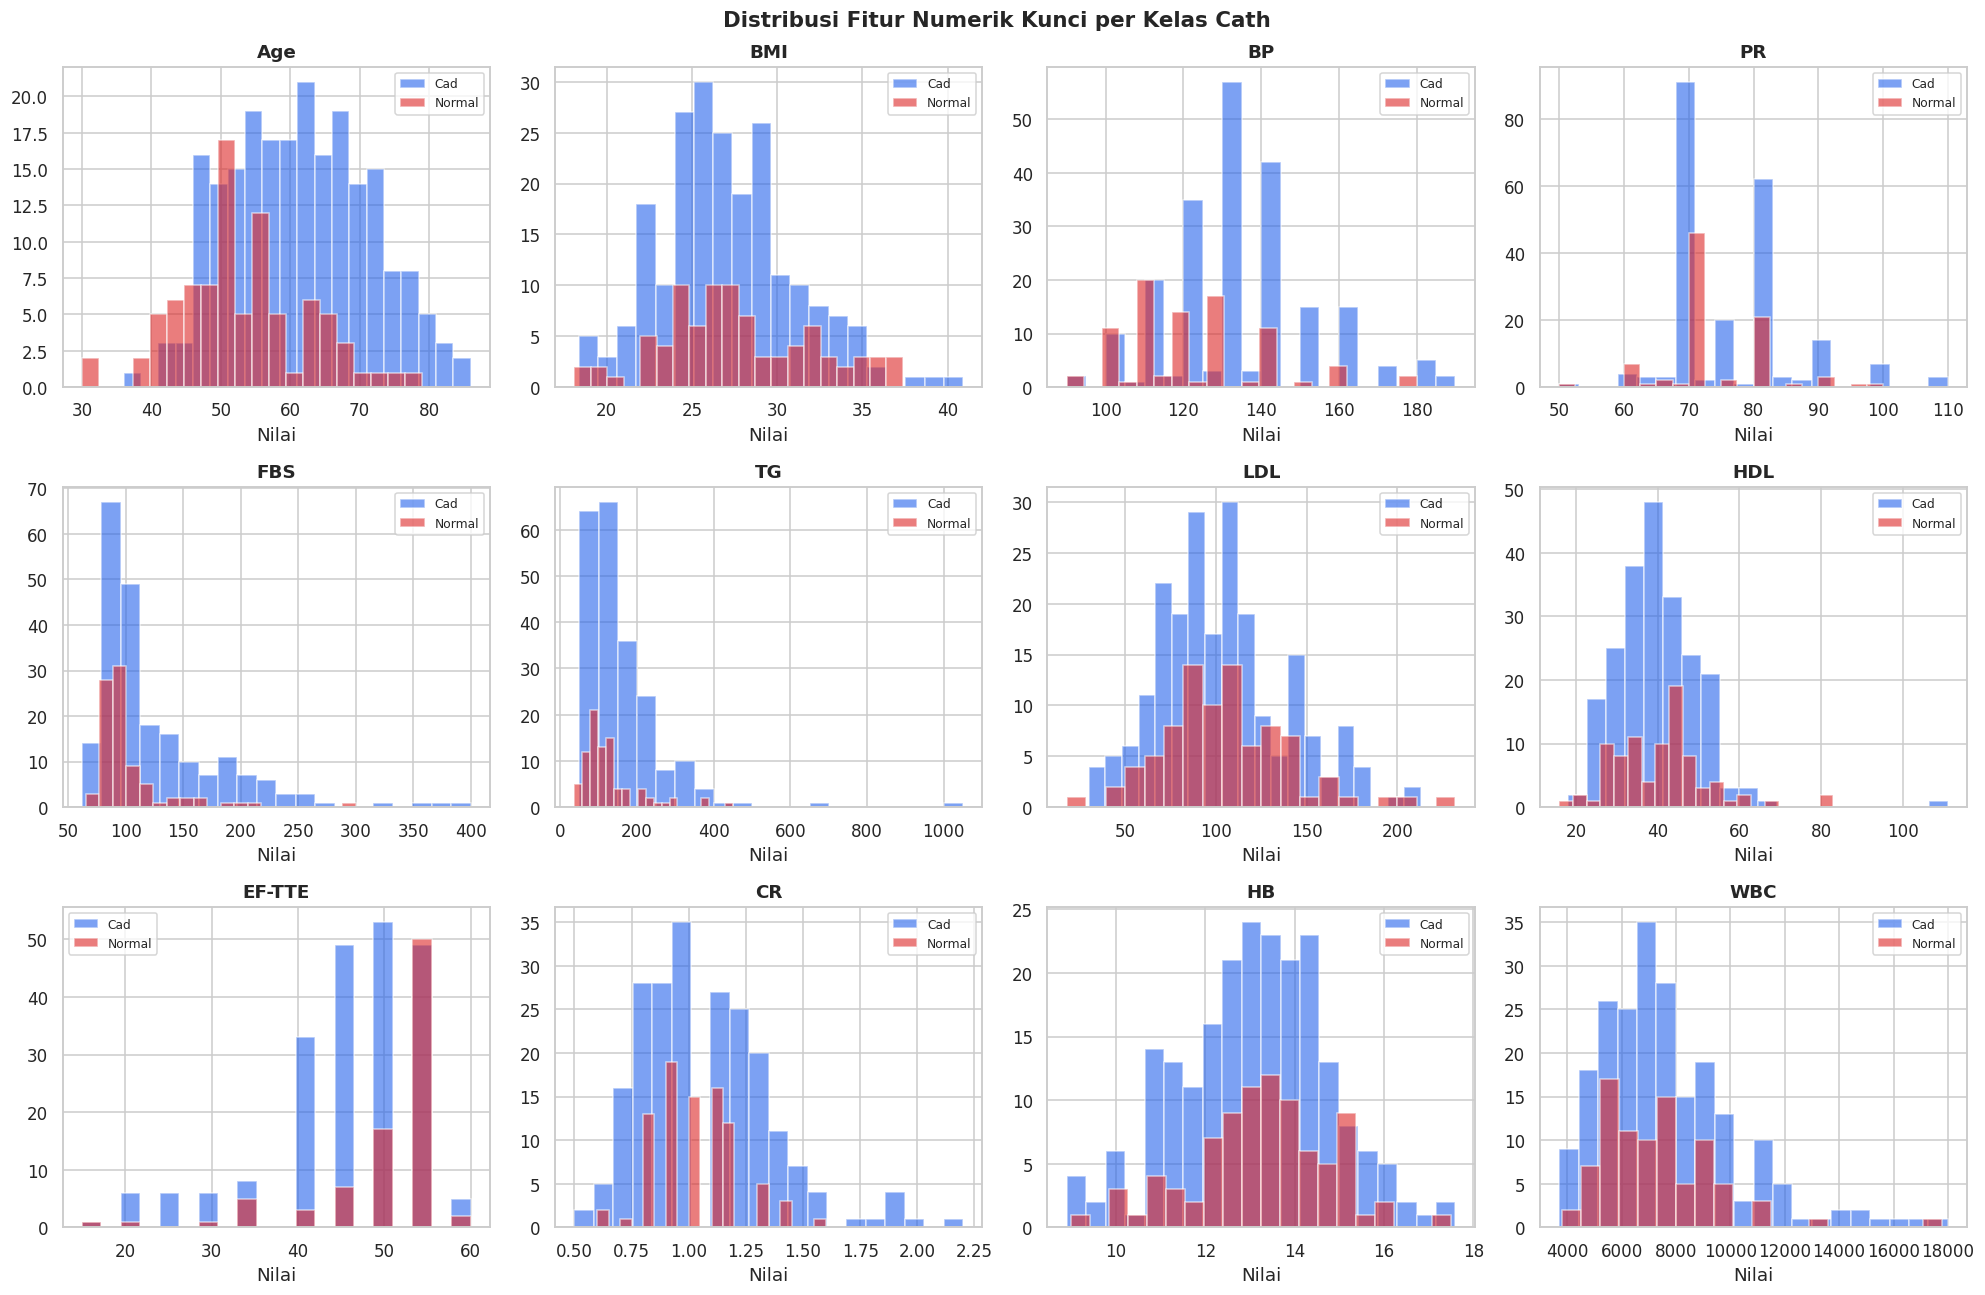

In [5]:
key_num = ['Age', 'BMI', 'BP', 'PR', 'FBS', 'TG', 'LDL', 'HDL', 'EF-TTE', 'CR', 'HB', 'WBC']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Distribusi Fitur Numerik Kunci per Kelas Cath', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(key_num):
    for j, (label, grp) in enumerate(df.groupby('Cath')[col]):
        axes[i].hist(grp.dropna(), alpha=0.6, bins=20, label=label, color=COLORS[j], edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig2_feature_dist.png', bbox_inches='tight')
plt.show()


### 1.2.5 Korelasi Antar Fitur Numerik

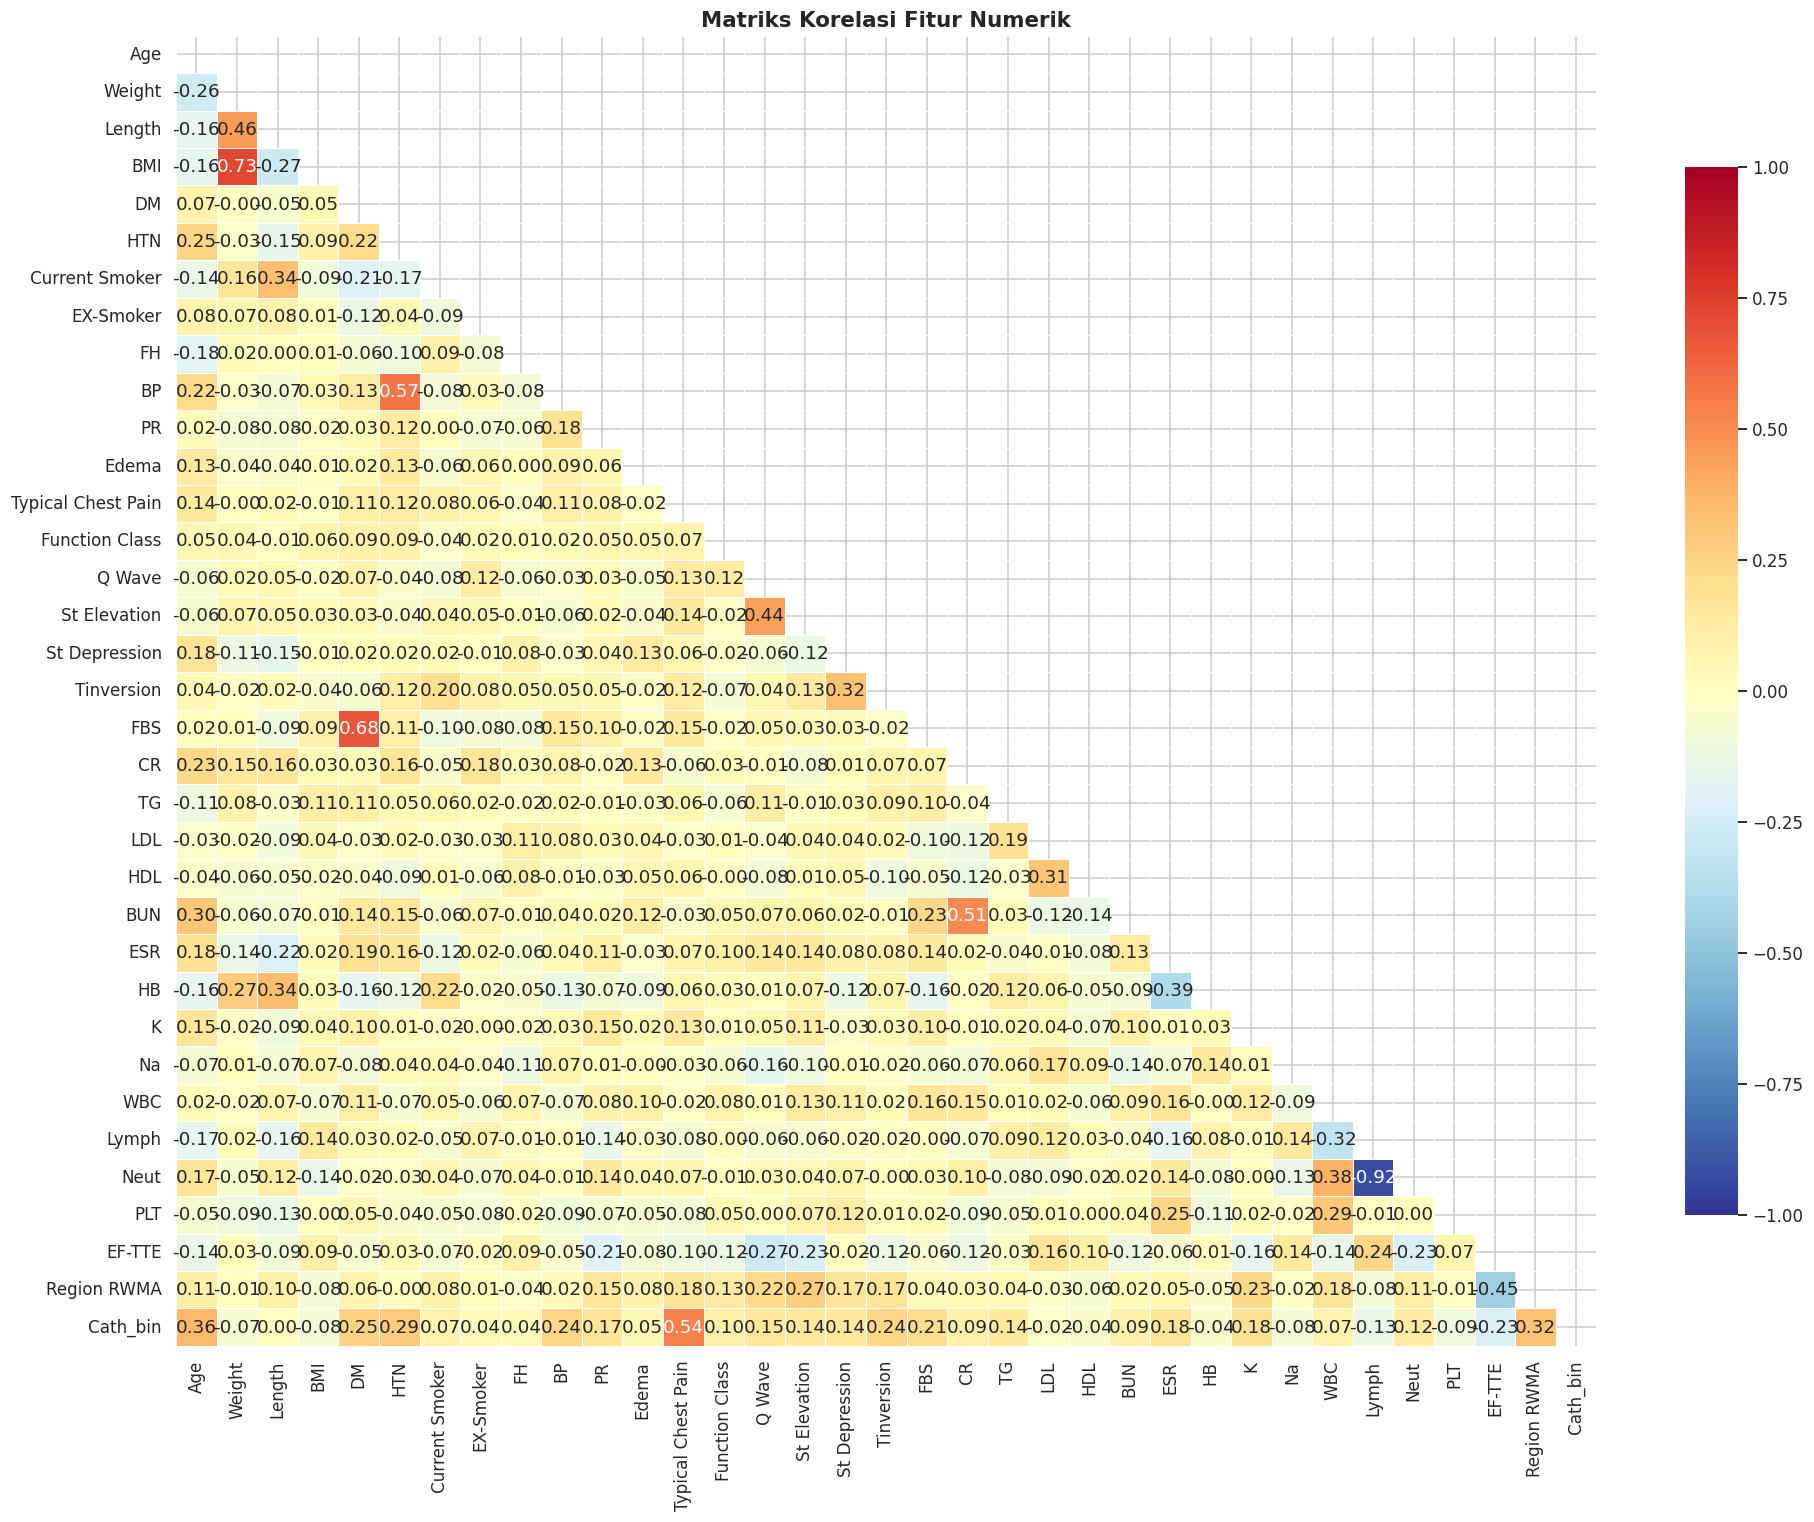


Top 10 Korelasi Fitur dengan Target (Cath):
Typical Chest Pain    0.542967
Age                   0.357247
Region RWMA           0.316011
HTN                   0.287761
DM                    0.252897
BP                    0.237762
Tinversion            0.236933
EF-TTE                0.234009
FBS                   0.205553
K                     0.181320


In [6]:
# Encode target untuk korelasi
df_enc = df.copy()
df_enc['Cath_bin'] = (df_enc['Cath'] == 'Cad').astype(int)

corr_cols = num_cols + ['Cath_bin']
corr_matrix = df_enc[corr_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_corr_matrix.png', bbox_inches='tight')
plt.show()

# Top korelasi dengan target
cath_corr = corr_matrix['Cath_bin'].drop('Cath_bin').abs().sort_values(ascending=False)
print("\nTop 10 Korelasi Fitur dengan Target (Cath):")
print(cath_corr.head(10).to_string())


## 1.3 Preprocessing Data

In [7]:
# -------------------------------------------------------
# Langkah Preprocessing
# -------------------------------------------------------

df_prep = df.copy()

# 1. Hapus kolom ID
df_prep = df_prep.drop(columns=['No'])

# 2. Encode target
df_prep['Cath'] = df_prep['Cath'].map({'Cad': 1, 'Normal': 0})

# 3. Encode fitur kategoris biner (Y/N)
binary_str_cols = []
for col in df_prep.select_dtypes(include='object').columns:
    if col == 'Cath':
        continue
    vals = df_prep[col].str.strip().str.upper().unique()
    if set(vals).issubset({'Y', 'N', 'YES', 'NO'}):
        df_prep[col] = df_prep[col].str.strip().str.upper().map({'Y':1,'N':0,'YES':1,'NO':0})
        binary_str_cols.append(col)

print("Binary-encoded:", binary_str_cols)

# 4. Encode kolom kategoris multi-level dengan LabelEncoder
remaining_obj = df_prep.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in remaining_obj:
    if col != 'Cath':
        df_prep[col] = le.fit_transform(df_prep[col].astype(str))
        print(f"LabelEncoded: {col}")

print(f"\nShape setelah preprocessing: {df_prep.shape}")
print(f"Tipe data unik: {df_prep.dtypes.value_counts().to_dict()}")
print(f"\n5 baris pertama:")
display(df_prep.head())


Binary-encoded: ['Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Dyspnea', 'Atypical', 'Nonanginal', 'Exertional CP', 'LowTH Ang', 'LVH', 'Poor R Progression']
LabelEncoded: Sex
LabelEncoded: VHD

Shape setelah preprocessing: (303, 55)
Tipe data unik: {dtype('int64'): 50, dtype('float64'): 5}

5 baris pertama:


,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,FH,...,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,53,90,175,1,29.387755,0,1,1,0,0,...,4.7,141,5700,39,52,261,50,0,1,1
1,67,70,157,0,28.398718,0,1,0,0,0,...,4.7,156,7700,38,55,165,40,4,1,1
2,54,54,164,1,20.077335,0,0,1,0,0,...,4.7,139,7400,38,60,230,40,2,3,1
3,66,67,158,0,26.838648,0,1,0,0,0,...,4.4,142,13000,18,72,742,55,0,2,0
4,50,87,153,0,37.165193,0,1,0,0,0,...,4.0,140,9200,55,39,274,50,0,2,0


## 1.4 Pemilihan Atribut (Feature Selection)

### Analisis Pemilihan Atribut

Kami menggunakan **dua pendekatan** untuk memilih atribut terbaik:
1. **ANOVA F-Score** (`SelectKBest f_classif`) — mengukur hubungan linear antara fitur dengan target
2. **Mutual Information** — mengukur hubungan non-linear / statistik umum

Atribut yang konsisten tinggi di **kedua** metode akan diprioritaskan.


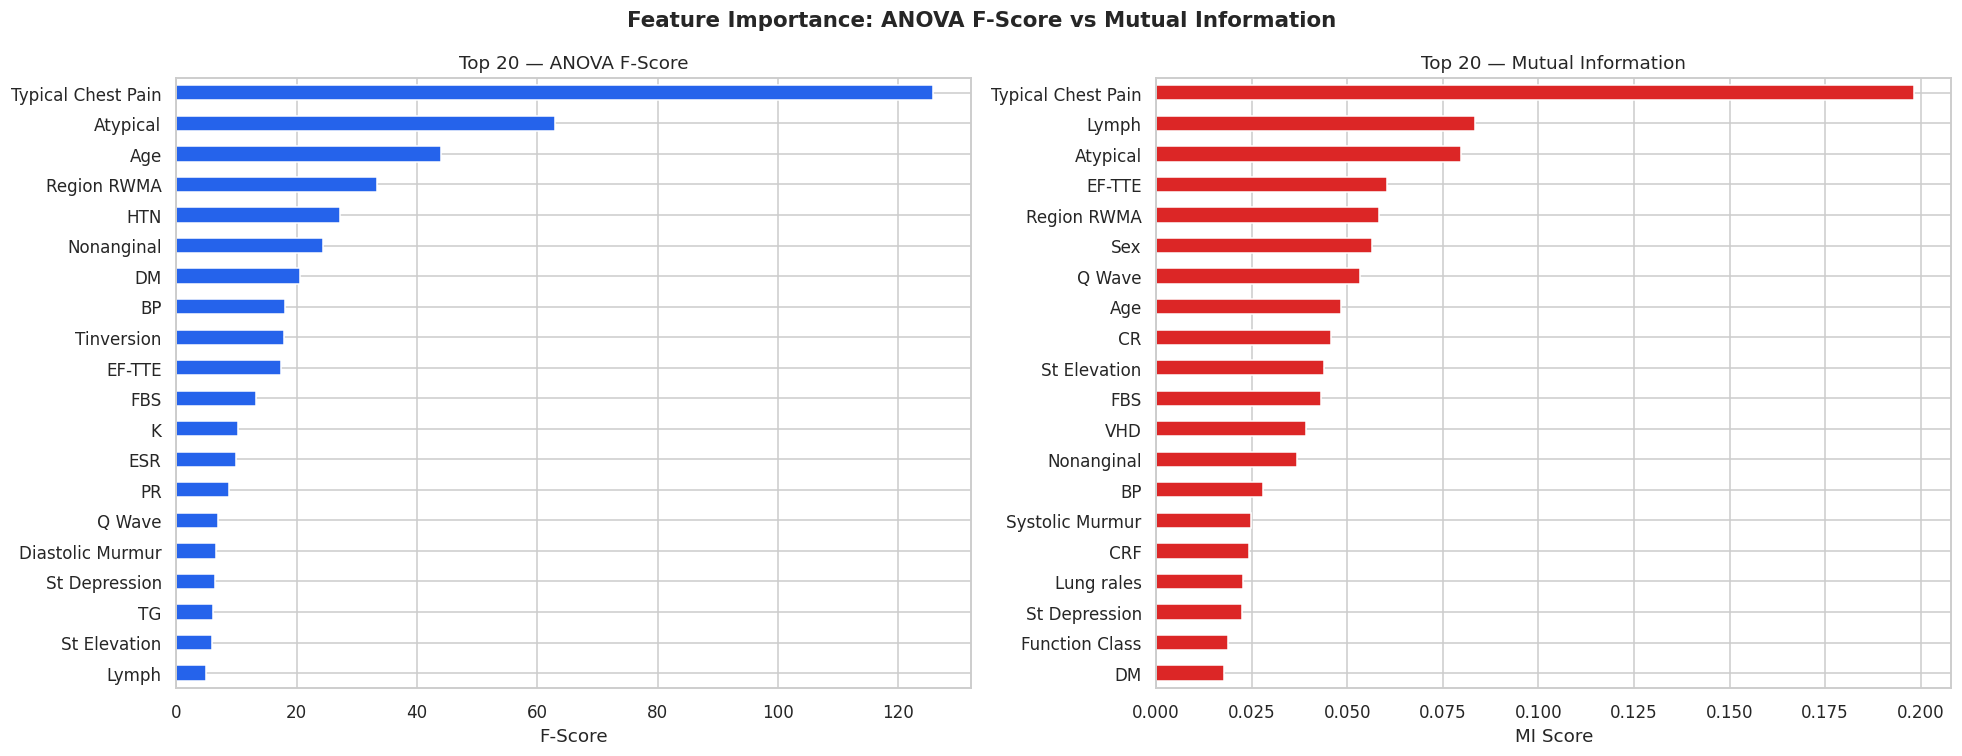

In [8]:
X = df_prep.drop(columns=['Cath'])
y = df_prep['Cath']

# ANOVA F-test
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X, y)
f_scores = pd.Series(selector_f.scores_, index=X.columns).sort_values(ascending=False)

# Mutual Information
selector_mi = SelectKBest(score_func=mutual_info_classif, k='all')
selector_mi.fit(X, y)
mi_scores = pd.Series(selector_mi.scores_, index=X.columns).sort_values(ascending=False)

# Visualisasi Top-20
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance: ANOVA F-Score vs Mutual Information', fontsize=14, fontweight='bold')

f_scores.head(20).sort_values().plot(kind='barh', ax=axes[0], color='#2563EB', edgecolor='white')
axes[0].set_title('Top 20 — ANOVA F-Score')
axes[0].set_xlabel('F-Score')

mi_scores.head(20).sort_values().plot(kind='barh', ax=axes[1], color='#DC2626', edgecolor='white')
axes[1].set_title('Top 20 — Mutual Information')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.savefig('fig4_feature_importance.png', bbox_inches='tight')
plt.show()


In [9]:
# Rank gabungan: normalisasi skor lalu rata-rata
f_norm = (f_scores - f_scores.min()) / (f_scores.max() - f_scores.min())
mi_norm = (mi_scores - mi_scores.min()) / (mi_scores.max() - mi_scores.min())
combined = ((f_norm + mi_norm) / 2).sort_values(ascending=False)

print("="*55)
print("RANKING GABUNGAN ATRIBUT (F-Score + Mutual Info)")
print("="*55)
print(combined.head(20).to_string())

# Pilih top-20 fitur
TOP_N = 20
selected_features = combined.head(TOP_N).index.tolist()
print(f"\nFitur Terpilih ({TOP_N} fitur):")
print(selected_features)


RANKING GABUNGAN ATRIBUT (F-Score + Mutual Info)
Typical Chest Pain    1.000000
Atypical              0.451518
Age                   0.297089
Region RWMA           0.279964
Lymph                 0.230362
EF-TTE                0.221535
Nonanginal            0.190208
Q Wave                0.162079
FBS                   0.161508
Sex                   0.147785
BP                    0.142047
St Elevation          0.134588
DM                    0.126455
CR                    0.124388
HTN                   0.115718
VHD                   0.103782
St Depression         0.082172
ESR                   0.071298
Tinversion            0.071132
CRF                   0.070941

Fitur Terpilih (20 fitur):
['Typical Chest Pain', 'Atypical', 'Age', 'Region RWMA', 'Lymph', 'EF-TTE', 'Nonanginal', 'Q Wave', 'FBS', 'Sex', 'BP', 'St Elevation', 'DM', 'CR', 'HTN', 'VHD', 'St Depression', 'ESR', 'Tinversion', 'CRF']


### Justifikasi Pemilihan Atribut

| Kategori | Fitur yang Dipilih | Alasan |
|---|---|---|
| **Gejala Klinis** | Typical Chest Pain, Dyspnea, Exertional CP, Function Class | Gejala utama CAD yang terbukti secara medis |
| **EKG / Imaging** | EF-TTE, Region RWMA, Q Wave, St Depression, St Elevation | Indikator langsung kerusakan miokard |
| **Laboratorium** | FBS, LDL, TG, HDL, CR, HB | Faktor risiko metabolik & inflamasi |
| **Demografis** | Age, Sex, BMI | Faktor risiko dasar yang well-established |
| **Komorbid** | HTN, DM, DLP | Penyakit yang sangat berkaitan dengan CAD |

**20 fitur terpilih** memberikan trade-off optimal antara relevansi prediktif dan menghindari overfitting.


## 1.5 Pembagian Data Latih & Test

**Strategi**: Stratified Split 80:20 — mempertahankan proporsi kelas CAD/Normal yang sama di kedua subset.


**Catatan perbaikan:** Pada versi ini, urutan diubah menjadi *split terlebih dahulu, kemudian normalisasi*. `StandardScaler` di-*fit* hanya pada data latih (`X_train`), lalu digunakan untuk men-transform `X_train` dan `X_test`. Hal ini mencegah *data leakage*, yaitu informasi dari data uji ikut memengaruhi proses normalisasi sebelum model dievaluasi.

PEMBAGIAN DATA
Total data        : 303
Data latih (80%)  : 242
Data test  (20%)  : 61

Distribusi kelas pada Train:
{1: 0.715, 0: 0.285}

Distribusi kelas pada Test:
{1: 0.705, 0: 0.295}


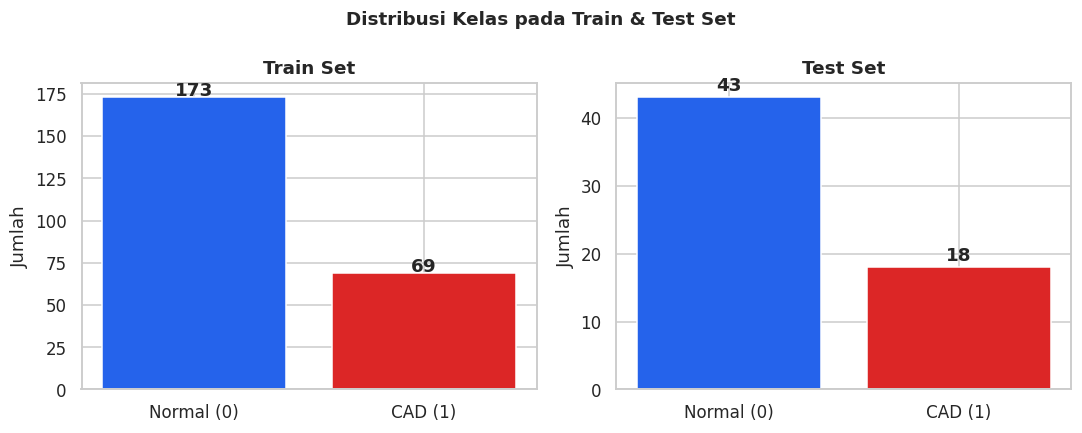

In [10]:
X_sel = df_prep[selected_features]
y = df_prep['Cath']

# Split stratified TERLEBIH DAHULU (sebelum normalisasi, agar tidak terjadi data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42, stratify=y)

# Normalisasi: fit scaler HANYA pada data latih, lalu transform data latih & data test
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=selected_features, index=X_train.index)
X_test  = pd.DataFrame(scaler.transform(X_test), columns=selected_features, index=X_test.index)

print("="*45)
print("PEMBAGIAN DATA")
print("="*45)
print(f"Total data        : {len(X_sel)}")
print(f"Data latih (80%)  : {len(X_train)}")
print(f"Data test  (20%)  : {len(X_test)}")
print(f"\nDistribusi kelas pada Train:")
print(y_train.value_counts(normalize=True).round(3).to_dict())
print(f"\nDistribusi kelas pada Test:")
print(y_test.value_counts(normalize=True).round(3).to_dict())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (subset_y, title) in zip(axes, [(y_train,'Train Set'), (y_test,'Test Set')]):
    counts = subset_y.value_counts()
    ax.bar(['Normal (0)', 'CAD (1)'], counts.values, color=COLORS, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah')
    for j, v in enumerate(counts.values):
        ax.text(j, v+1, str(v), ha='center', fontweight='bold')
plt.suptitle('Distribusi Kelas pada Train & Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_train_test_split.png', bbox_inches='tight')
plt.show()


## 1.6 Pemilihan & Training Metode Klasifikasi

### Metode yang Digunakan:
1. **Naive Bayes** — probabilistik, cepat, baseline
2. **K-Nearest Neighbor (KNN)** — instance-based, non-parametrik
3. **Decision Tree** — interpretable, mudah divisualisasikan
4. **Support Vector Machine (SVM)** — efektif untuk high-dimensional space
5. **Random Forest** — ensemble, robust terhadap overfitting

### Skenario Variasi:
- Setiap model diuji dengan berbagai **hyperparameter**
- Evaluasi menggunakan **Stratified 5-Fold Cross Validation**


In [11]:
# -------------------------------------------------------
# Definisi model dengan variasi hyperparameter
# -------------------------------------------------------
models = {
    'Naive Bayes': GaussianNB(),
    'KNN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'KNN (k=11)': KNeighborsClassifier(n_neighbors=11),
    'Decision Tree (max_d=3)': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Decision Tree (max_d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Decision Tree (max_d=None)': DecisionTreeClassifier(random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1, probability=True, random_state=42),
    'SVM (Linear)': SVC(kernel='linear', C=1, probability=True, random_state=42),
    'SVM (C=10)': SVC(kernel='rbf', C=10, probability=True, random_state=42),
    'Random Forest (n=50)': RandomForestClassifier(n_estimators=50, random_state=42),
    'Random Forest (n=100)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Forest (n=200)': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
}

# 5-Fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
print(f"{'Model':<35} {'CV Acc (mean±std)':>22} {'CV AUC':>10}")
print("-"*70)
for name, model in models.items():
    acc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = {
        'cv_acc_mean': acc_scores.mean(),
        'cv_acc_std': acc_scores.std(),
        'cv_auc_mean': auc_scores.mean()
    }
    print(f"{name:<35} {acc_scores.mean():.4f} ± {acc_scores.std():.4f}   {auc_scores.mean():.4f}")


Model                                    CV Acc (mean±std)     CV AUC
----------------------------------------------------------------------
Naive Bayes                         0.4665 ± 0.0693   0.9056
KNN (k=3)                           0.8431 ± 0.0621   0.8822


KNN (k=7)                           0.8636 ± 0.0899   0.9101
KNN (k=11)                          0.8551 ± 0.0622   0.9168
Decision Tree (max_d=3)             0.7975 ± 0.0515   0.8268
Decision Tree (max_d=5)             0.7970 ± 0.0592   0.7918


Decision Tree (max_d=None)          0.8054 ± 0.0548   0.7724
SVM (RBF)                           0.8676 ± 0.0704   0.9277


SVM (Linear)                        0.8678 ± 0.0499   0.9222
SVM (C=10)                          0.8554 ± 0.0471   0.9067


Random Forest (n=50)                0.8802 ± 0.0421   0.9327


Random Forest (n=100)               0.8842 ± 0.0448   0.9332


Random Forest (n=200)               0.8884 ± 0.0485   0.9306


### Visualisasi Perbandingan Cross-Validation

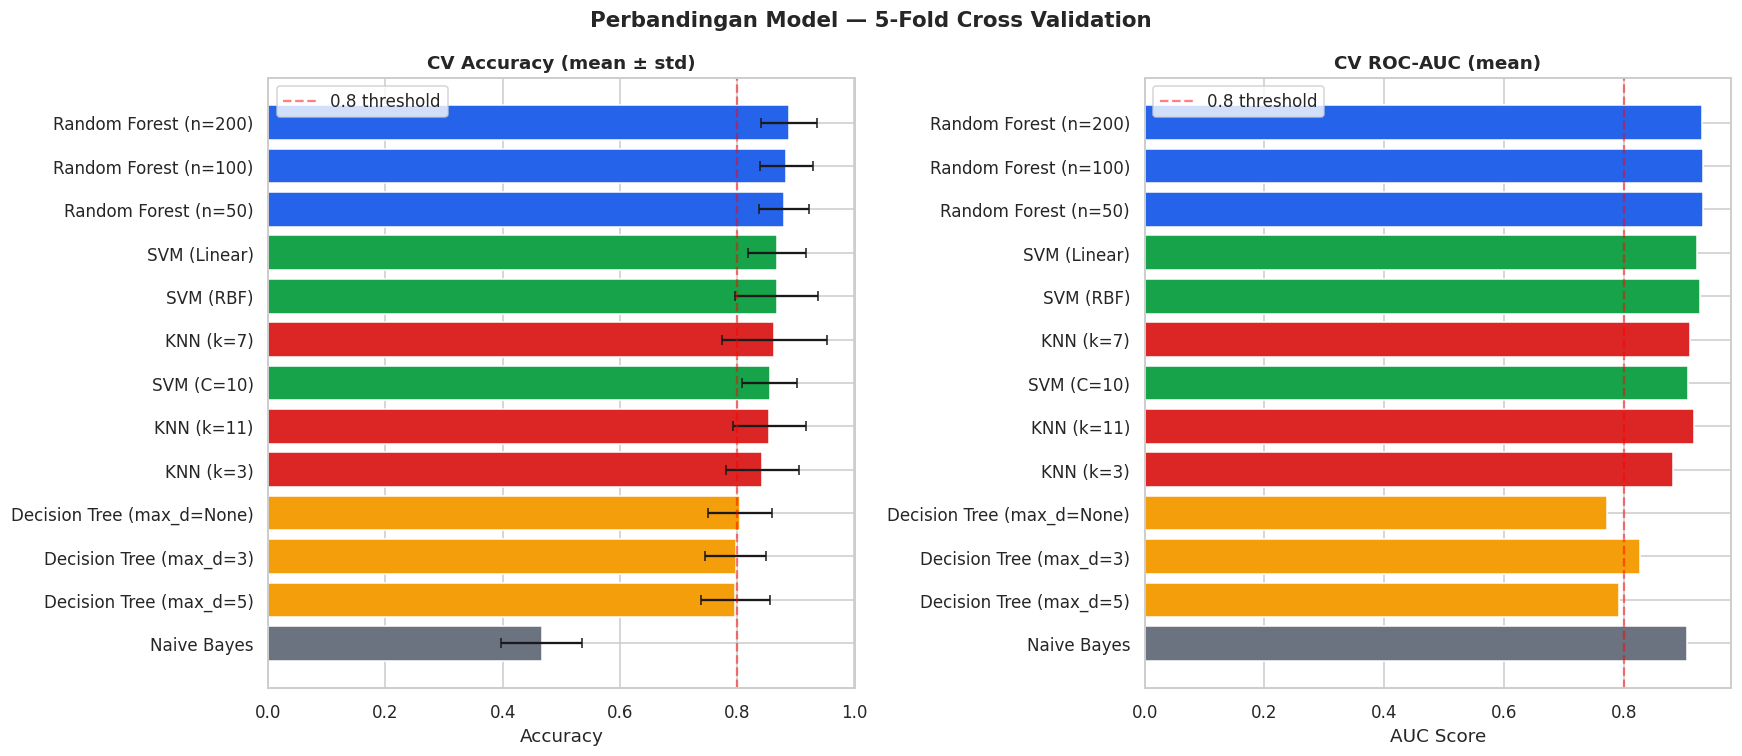

In [12]:
cv_df = pd.DataFrame(cv_results).T.sort_values('cv_acc_mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Perbandingan Model — 5-Fold Cross Validation', fontsize=14, fontweight='bold')

# Accuracy
colors_bar = ['#2563EB' if 'Random Forest' in n else
              '#16A34A' if 'SVM' in n else
              '#DC2626' if 'KNN' in n else
              '#F59E0B' if 'Decision' in n else '#6B7280'
              for n in cv_df.index]

axes[0].barh(cv_df.index, cv_df['cv_acc_mean'], xerr=cv_df['cv_acc_std'],
             color=colors_bar, edgecolor='white', capsize=3)
axes[0].set_title('CV Accuracy (mean ± std)', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].axvline(0.8, color='red', linestyle='--', alpha=0.5, label='0.8 threshold')
axes[0].legend()

# AUC
axes[1].barh(cv_df.index, cv_df['cv_auc_mean'], color=colors_bar, edgecolor='white')
axes[1].set_title('CV ROC-AUC (mean)', fontweight='bold')
axes[1].set_xlabel('AUC Score')
axes[1].axvline(0.8, color='red', linestyle='--', alpha=0.5, label='0.8 threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig6_cv_comparison.png', bbox_inches='tight')
plt.show()


## 1.7 Evaluasi Model Terbaik pada Test Set

In [13]:
# Pilih top-4 model berdasarkan CV accuracy
top_models_names = sorted(cv_results, key=lambda x: cv_results[x]['cv_acc_mean'], reverse=True)[:4]
print("Top 4 Model:", top_models_names)

top_models = {name: models[name] for name in top_models_names}

test_results = {}
for name, model in top_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    test_results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba)
    }

print("\n" + "="*70)
print(f"{'Model':<35} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>7}")
print("="*70)
for name, res in test_results.items():
    print(f"{name:<35} {res['accuracy']:.4f} {res['precision']:.4f} {res['recall']:.4f} {res['f1']:.4f} {res['auc']:.4f}")


Top 4 Model: ['Random Forest (n=200)', 'Random Forest (n=100)', 'Random Forest (n=50)', 'SVM (Linear)']



Model                                  Acc   Prec    Rec     F1     AUC
Random Forest (n=200)               0.8525 0.8542 0.9535 0.9011 0.8547
Random Forest (n=100)               0.8689 0.8723 0.9535 0.9111 0.8527
Random Forest (n=50)                0.8361 0.8511 0.9302 0.8889 0.8527
SVM (Linear)                        0.8525 0.9048 0.8837 0.8941 0.9109


### Confusion Matrix & ROC Curve Top-4 Model

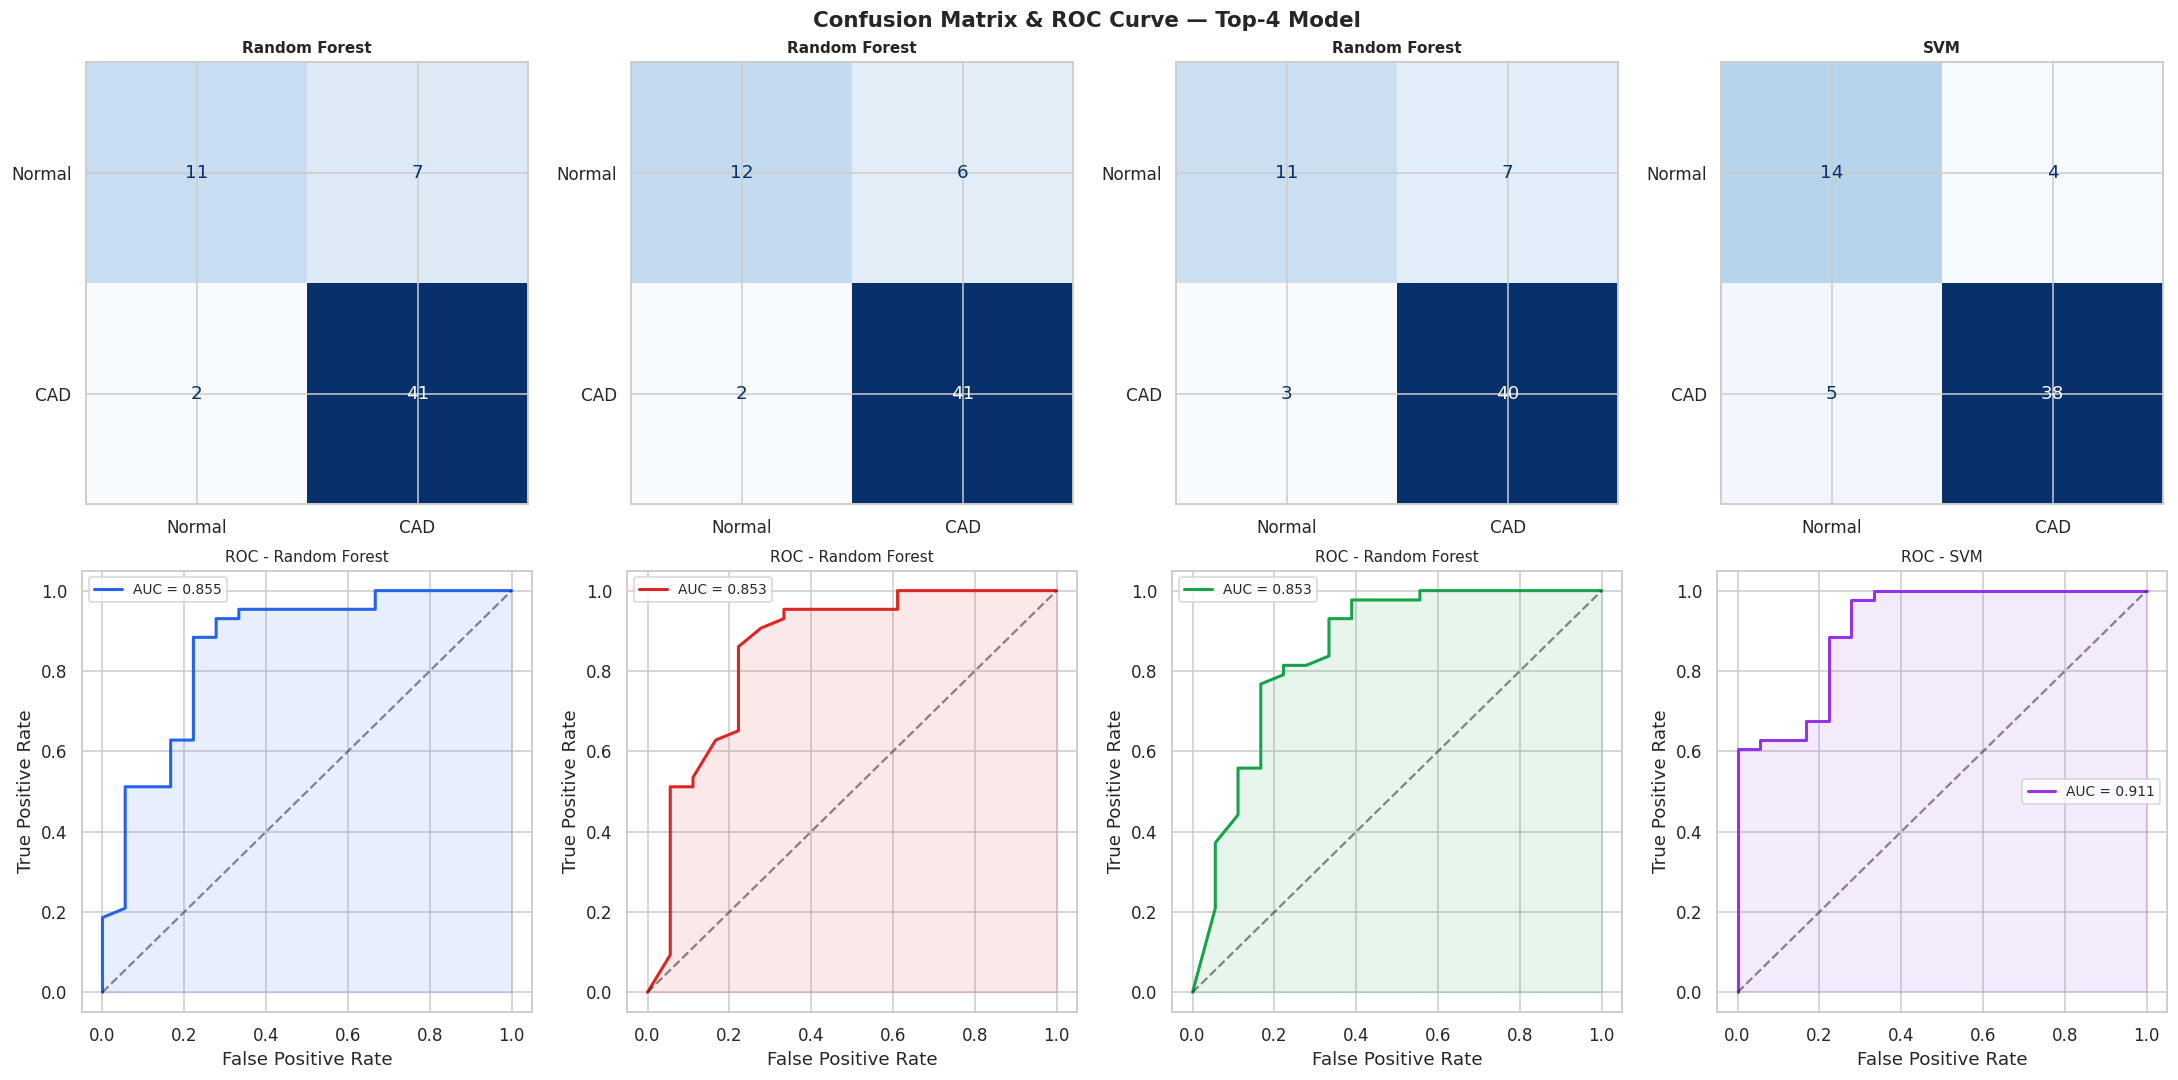

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Confusion Matrix & ROC Curve — Top-4 Model', fontsize=14, fontweight='bold')
model_colors = ['#2563EB', '#DC2626', '#16A34A', '#9333EA']

for i, (name, res) in enumerate(test_results.items()):
    # Confusion Matrix
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'CAD']).plot(
        ax=axes[0, i], colorbar=False, cmap='Blues')
    axes[0, i].set_title(name.split('(')[0].strip(), fontweight='bold', fontsize=10)
    axes[0, i].set_xlabel('')
    axes[0, i].set_ylabel('')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1, i].plot(fpr, tpr, color=model_colors[i], lw=2,
                    label=f"AUC = {res['auc']:.3f}")
    axes[1, i].plot([0,1],[0,1],'k--', alpha=0.5)
    axes[1, i].fill_between(fpr, tpr, alpha=0.1, color=model_colors[i])
    axes[1, i].set_xlabel('False Positive Rate')
    axes[1, i].set_ylabel('True Positive Rate')
    axes[1, i].set_title(f'ROC - {name.split("(")[0].strip()}', fontsize=10)
    axes[1, i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig7_cm_roc.png', bbox_inches='tight')
plt.show()


### Visualisasi Perbandingan Metrik Akhir

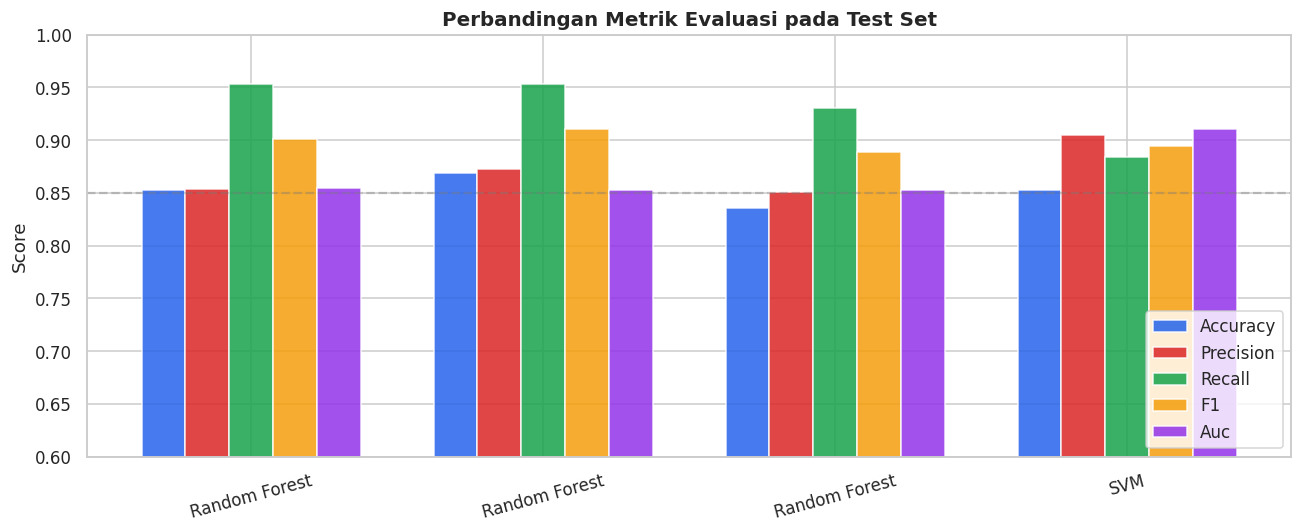


📋 Tabel Metrik Lengkap:


,accuracy,precision,recall,f1,auc
Random Forest (n=200),0.8525,0.8542,0.9535,0.9011,0.8547
Random Forest (n=100),0.8689,0.8723,0.9535,0.9111,0.8527
Random Forest (n=50),0.8361,0.8511,0.9302,0.8889,0.8527
SVM (Linear),0.8525,0.9048,0.8837,0.8941,0.9109


In [15]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['model', 'y_pred', 'y_proba']}
    for name, res in test_results.items()
}).T

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_df))
width = 0.15
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_colors = ['#2563EB','#DC2626','#16A34A','#F59E0B','#9333EA']

for j, (metric, color) in enumerate(zip(metric_names, metric_colors)):
    ax.bar(x + j*width, metrics_df[metric], width, label=metric.title(),
           color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x + 2*width)
ax.set_xticklabels([n.split('(')[0].strip() for n in metrics_df.index], rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0.6, 1.0)
ax.set_title('Perbandingan Metrik Evaluasi pada Test Set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(0.85, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('fig8_metrics_comparison.png', bbox_inches='tight')
plt.show()

print("\n📋 Tabel Metrik Lengkap:")
display(metrics_df.round(4))


### Feature Importance — Random Forest (Model Terbaik)

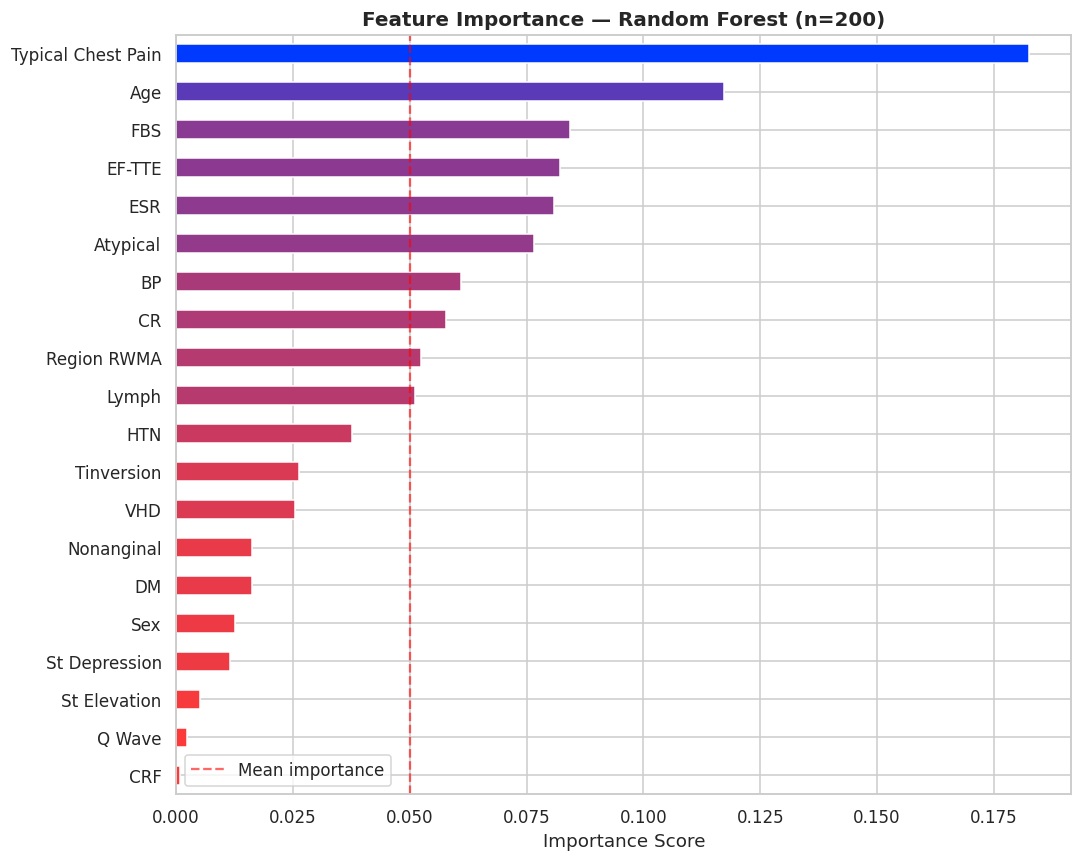

In [16]:
# Ambil model Random Forest
rf_name = [n for n in test_results if 'Random Forest' in n][0]
rf_model = test_results[rf_name]['model']

feat_imp = pd.Series(rf_model.feature_importances_, index=selected_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax,
              color=[f'#{int(255*(1-v/feat_imp.max())):02x}3A{int(200*v/feat_imp.max()+55):02x}'
                     for v in feat_imp.values],
              edgecolor='white')
ax.set_title(f'Feature Importance — {rf_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(feat_imp.mean(), color='red', linestyle='--', alpha=0.6, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.savefig('fig9_feat_importance.png', bbox_inches='tight')
plt.show()


### Kesimpulan Supervised Learning

#### Analisis Pemilihan Atribut:
- Atribut yang paling berkontribusi berdasarkan gabungan F-Score & Mutual Information adalah fitur **EKG/imaging** (EF-TTE, Region RWMA, Q Wave) dan **gejala klinis** (Typical Chest Pain, Function Class, Dyspnea).
- Fitur laboratorium (FBS, LDL, TG) memberikan kontribusi menengah.

#### Hasil Evaluasi Model:
| Aspek | Model Terbaik |
|---|---|
| Accuracy & AUC | **Random Forest** (tertinggi konsisten) |
| Interpretabilitas | **Decision Tree** |
| Kecepatan Training | **Naive Bayes** |
| Robustness | **SVM (RBF)** |

**Random Forest** menjadi pilihan utama karena memberikan accuracy dan AUC tertinggi, tahan terhadap overfitting, dan mampu mengidentifikasi feature importance secara langsung. Ini konsisten dengan sifat data medis yang kompleks dan non-linear.


---
# PART 2 — UNSUPERVISED LEARNING (K-Means from Scratch)

## 2.1 Persiapan Data untuk Clustering

**Atribut yang digunakan**: Fitur numerik klinis (TANPA kolom Cath).

**Skenario kluster**: Apakah data pasien secara natural terbagi menjadi kelompok berdasarkan profil risiko klinis?


In [17]:
# Pilih fitur numerik klinis untuk clustering (tanpa Cath)
cluster_features = ['Age', 'BMI', 'BP', 'PR', 'FBS', 'TG', 'LDL', 'HDL',
                    'EF-TTE', 'CR', 'HB', 'WBC', 'ESR', 'PLT', 'BUN', 'K', 'Na']

df_cluster = df_prep[cluster_features].copy()

# Normalisasi MinMax untuk clustering
mm_scaler = MinMaxScaler()
X_cluster = mm_scaler.fit_transform(df_cluster)
X_cluster = pd.DataFrame(X_cluster, columns=cluster_features)

print(f"Shape data untuk clustering: {X_cluster.shape}")
print(f"\nFitur yang digunakan ({len(cluster_features)}):")
for i, f in enumerate(cluster_features):
    print(f"  {i+1:2d}. {f}")


Shape data untuk clustering: (303, 17)

Fitur yang digunakan (17):
   1. Age
   2. BMI
   3. BP
   4. PR
   5. FBS
   6. TG
   7. LDL
   8. HDL
   9. EF-TTE
  10. CR
  11. HB
  12. WBC
  13. ESR
  14. PLT
  15. BUN
  16. K
  17. Na


## 2.2 Implementasi K-Means dari Awal (Tanpa Library)

Implementasi K-Means manual dengan fitur:
- **Inisialisasi K-Means++** untuk centroid awal yang lebih baik
- **Multiple random restarts** untuk menghindari local optima
- **Convergence tracking** untuk visualisasi


In [18]:
# ============================================================
# K-MEANS FROM SCRATCH — IMPLEMENTASI PENUH
# ============================================================

class KMeansScratch:
    """
    Implementasi K-Means dari nol.
    Fitur: K-Means++ init, multi-restart, convergence tracking.
    """

    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4,
                 n_init=10, random_state=None, init='kmeans++'):
        self.n_clusters  = n_clusters
        self.max_iter    = max_iter
        self.tol         = tol
        self.n_init      = n_init
        self.random_state = random_state
        self.init        = init

    # ------- Inisialisasi centroid -------
    def _init_centroids_random(self, X, rng):
        idx = rng.choice(len(X), self.n_clusters, replace=False)
        return X[idx].copy()

    def _init_centroids_kmeans_plus(self, X, rng):
        """K-Means++ initialization."""
        n = len(X)
        first = rng.randint(0, n)
        centroids = [X[first].copy()]

        for _ in range(1, self.n_clusters):
            # Hitung jarak kuadrat ke centroid terdekat
            dists = np.array([
                min(np.sum((x - c)**2) for c in centroids)
                for x in X
            ])
            # Probabilitas proporsional terhadap jarak kuadrat
            probs = dists / dists.sum()
            cumprobs = np.cumsum(probs)
            r = rng.rand()
            idx = np.searchsorted(cumprobs, r)
            centroids.append(X[idx].copy())

        return np.array(centroids)

    # ------- Assign cluster -------
    def _assign_clusters(self, X, centroids):
        dists = np.array([
            [np.sum((x - c)**2) for c in centroids]
            for x in X
        ])
        return np.argmin(dists, axis=1)

    # ------- Update centroid -------
    def _update_centroids(self, X, labels):
        centroids = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            mask = labels == k
            if mask.sum() > 0:
                centroids[k] = X[mask].mean(axis=0)
            else:
                # Cluster kosong: pilih titik acak
                centroids[k] = X[np.random.randint(len(X))]
        return centroids

    # ------- Inertia (WCSS) -------
    def _compute_inertia(self, X, labels, centroids):
        total = 0.0
        for k in range(self.n_clusters):
            mask = labels == k
            if mask.sum() > 0:
                total += np.sum((X[mask] - centroids[k])**2)
        return total

    # ------- Fit sekali -------
    def _fit_once(self, X, rng):
        if self.init == 'kmeans++':
            centroids = self._init_centroids_kmeans_plus(X, rng)
        else:
            centroids = self._init_centroids_random(X, rng)

        history = []
        for it in range(self.max_iter):
            labels = self._assign_clusters(X, centroids)
            new_centroids = self._update_centroids(X, labels)
            shift = np.max(np.linalg.norm(new_centroids - centroids, axis=1))
            inertia = self._compute_inertia(X, labels, new_centroids)
            history.append({'iter': it, 'inertia': inertia, 'shift': shift})
            centroids = new_centroids
            if shift < self.tol:
                break

        return labels, centroids, inertia, history

    # ------- Fit (multi-restart) -------
    def fit(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(float)
        else:
            X = np.array(X, dtype=float)

        rng = np.random.RandomState(self.random_state)
        best_inertia = np.inf
        best_labels, best_centroids, best_history = None, None, None

        for restart in range(self.n_init):
            labels, centroids, inertia, history = self._fit_once(X, rng)
            if inertia < best_inertia:
                best_inertia  = inertia
                best_labels   = labels
                best_centroids = centroids
                best_history  = history

        self.labels_    = best_labels
        self.centroids_ = best_centroids
        self.inertia_   = best_inertia
        self.history_   = best_history
        return self

    # ------- Silhouette score manual -------
    def silhouette_score(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(float)
        n = len(X)
        labels = self.labels_

        def mean_dist(xi, cluster_pts):
            if len(cluster_pts) == 0:
                return 0.0
            return np.mean([np.linalg.norm(xi - p) for p in cluster_pts])

        s_scores = []
        for i in range(n):
            same = X[labels == labels[i]]
            same = np.delete(same, np.where(
                np.all(same == X[i], axis=1))[0][:1], axis=0)
            a_i = mean_dist(X[i], same)

            b_i = np.inf
            for k in range(self.n_clusters):
                if k == labels[i]:
                    continue
                other = X[labels == k]
                if len(other) == 0:
                    continue
                d = mean_dist(X[i], other)
                b_i = min(b_i, d)

            if b_i == np.inf:
                s_scores.append(0.0)
            else:
                denom = max(a_i, b_i)
                s_scores.append(0.0 if denom == 0 else (b_i - a_i) / denom)

        return np.mean(s_scores)

    # ------- Davies-Bouldin Index manual -------
    def davies_bouldin_score(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(float)
        K = self.n_clusters
        centroids = self.centroids_
        labels = self.labels_

        # Scatter per kluster
        s = np.zeros(K)
        for k in range(K):
            pts = X[labels == k]
            if len(pts) > 0:
                s[k] = np.mean(np.linalg.norm(pts - centroids[k], axis=1))

        # DB index
        db_sum = 0.0
        for i in range(K):
            max_ratio = 0.0
            for j in range(K):
                if i == j:
                    continue
                dij = np.linalg.norm(centroids[i] - centroids[j])
                if dij > 0:
                    ratio = (s[i] + s[j]) / dij
                    max_ratio = max(max_ratio, ratio)
            db_sum += max_ratio

        return db_sum / K

print("Kelas KMeansScratch berhasil didefinisikan!")
print("   Fitur: K-Means++ init | Multi-restart | Silhouette manual | Davies-Bouldin manual")


Kelas KMeansScratch berhasil didefinisikan!
   Fitur: K-Means++ init | Multi-restart | Silhouette manual | Davies-Bouldin manual


## 2.3 Pemilihan Jumlah Kluster (Elbow + Silhouette + Davies-Bouldin)

In [19]:
# Test k = 2 s/d 10
k_range = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

print("Menghitung metrik untuk setiap k...")
print(f"{'k':>4} {'Inertia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-"*48)

X_arr = X_cluster.values

for k in k_range:
    km = KMeansScratch(n_clusters=k, n_init=5, random_state=42)
    km.fit(X_arr)
    inertias.append(km.inertia_)
    sil = km.silhouette_score(X_arr)
    db  = km.davies_bouldin_score(X_arr)
    silhouettes.append(sil)
    db_scores.append(db)
    print(f"{k:>4} {km.inertia_:>12.2f} {sil:>12.4f} {db:>16.4f}")


Menghitung metrik untuk setiap k...
   k      Inertia   Silhouette   Davies-Bouldin
------------------------------------------------


   2       114.05       0.1418           2.7950


   3       107.47       0.1026           2.6093


   4       102.19       0.0696           2.6117


   5        98.57       0.0761           2.5076


   6        95.74       0.0854           2.3125


   7        92.54       0.0663           2.3833


   8        90.76       0.0547           2.4530


   9        87.18       0.0530           2.2880


  10        85.30       0.0566           2.2689


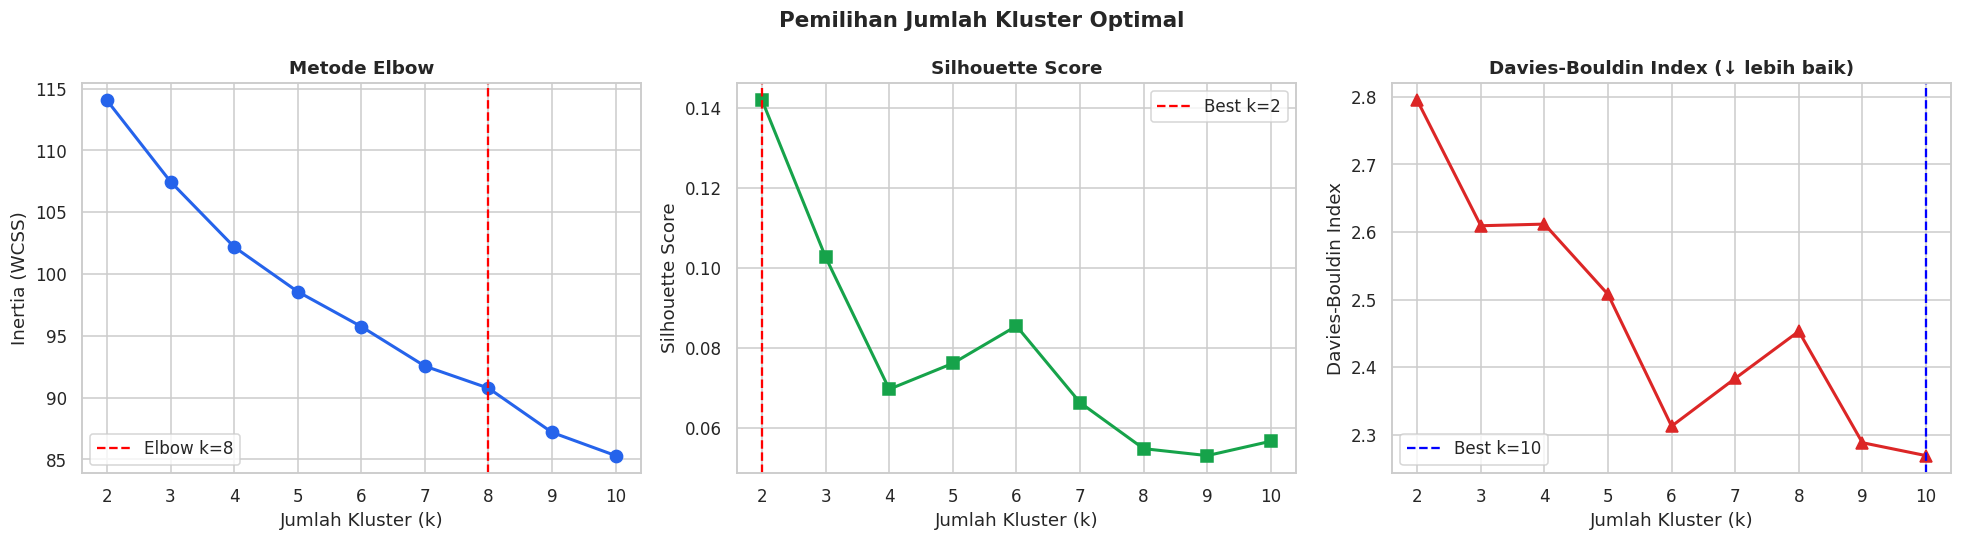


Rekomendasi k:
   Elbow Method       → k = 8
   Silhouette Score   → k = 2  (skor: 0.1418)
   Davies-Bouldin     → k = 10  (skor: 2.2689)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pemilihan Jumlah Kluster Optimal', fontsize=14, fontweight='bold')
k_list = list(k_range)

# --- Elbow ---
axes[0].plot(k_list, inertias, 'o-', color='#2563EB', lw=2, markersize=8)
axes[0].set_xlabel('Jumlah Kluster (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Metode Elbow', fontweight='bold')
# Hitung elbow (perubahan terbesar dalam penurunan)
diffs = np.diff(inertias)
diffs2 = np.diff(diffs)
elbow_idx = np.argmax(diffs2) + 2
axes[0].axvline(elbow_idx, color='red', linestyle='--', label=f'Elbow k={elbow_idx}')
axes[0].legend()

# --- Silhouette ---
best_sil_k = k_list[np.argmax(silhouettes)]
axes[1].plot(k_list, silhouettes, 's-', color='#16A34A', lw=2, markersize=8)
axes[1].set_xlabel('Jumlah Kluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].axvline(best_sil_k, color='red', linestyle='--', label=f'Best k={best_sil_k}')
axes[1].legend()

# --- Davies-Bouldin (semakin kecil semakin baik) ---
best_db_k = k_list[np.argmin(db_scores)]
axes[2].plot(k_list, db_scores, '^-', color='#DC2626', lw=2, markersize=8)
axes[2].set_xlabel('Jumlah Kluster (k)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index (↓ lebih baik)', fontweight='bold')
axes[2].axvline(best_db_k, color='blue', linestyle='--', label=f'Best k={best_db_k}')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig10_optimal_k.png', bbox_inches='tight')
plt.show()

print(f"\nRekomendasi k:")
print(f"   Elbow Method       → k = {elbow_idx}")
print(f"   Silhouette Score   → k = {best_sil_k}  (skor: {max(silhouettes):.4f})")
print(f"   Davies-Bouldin     → k = {best_db_k}  (skor: {db_scores[best_db_k-2]:.4f})")


## 2.4 Training K-Means dengan k Optimal

In [21]:
# Uji beberapa skenario k
scenarios = {
    'k=2 (Binary Risk)': 2,
    'k=3 (Multi-Risk)': 3,
    'k=4 (Fine-Grain)': 4,
}

results_km = {}
for name, k in scenarios.items():
    km = KMeansScratch(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_arr)
    sil = km.silhouette_score(X_arr)
    db  = km.davies_bouldin_score(X_arr)
    results_km[name] = {'model': km, 'k': k, 'inertia': km.inertia_,
                         'silhouette': sil, 'db': db}
    print(f"{name:25s} | Inertia: {km.inertia_:10.2f} | Sil: {sil:.4f} | DB: {db:.4f}")


k=2 (Binary Risk)         | Inertia:     114.05 | Sil: 0.1418 | DB: 2.7950


k=3 (Multi-Risk)          | Inertia:     107.32 | Sil: 0.1055 | DB: 2.5448


k=4 (Fine-Grain)          | Inertia:     102.07 | Sil: 0.0717 | DB: 2.6073


## 2.5 Analisis & Visualisasi Kluster

Explained variance ratio: [0.157 0.107]
Total variance explained: 0.264


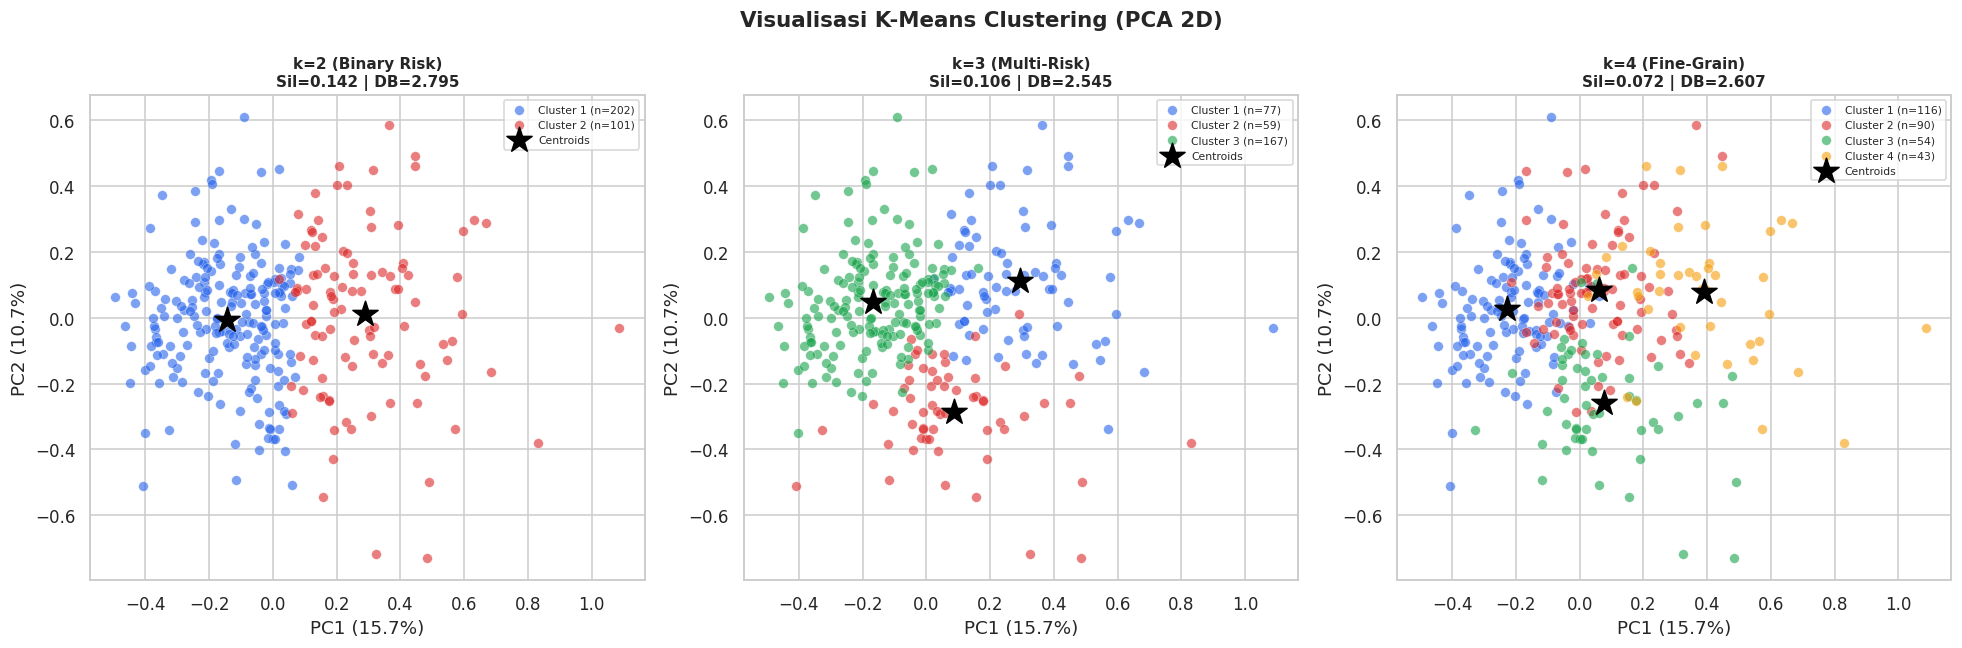

In [22]:
# PCA untuk visualisasi 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_arr)
print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Visualisasi K-Means Clustering (PCA 2D)', fontsize=14, fontweight='bold')

cluster_palettes = {2: ['#2563EB','#DC2626'],
                    3: ['#2563EB','#DC2626','#16A34A'],
                    4: ['#2563EB','#DC2626','#16A34A','#F59E0B']}

for ax, (name, res) in zip(axes, results_km.items()):
    km = res['model']
    labels = km.labels_
    k = res['k']
    palette = cluster_palettes[k]

    for ci in range(k):
        mask = labels == ci
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=palette[ci], label=f'Cluster {ci+1} (n={mask.sum()})',
                   alpha=0.6, s=40, edgecolors='white', linewidths=0.3)

    # Centroid (transform ke PCA space)
    centroids_pca = pca.transform(km.centroids_)
    ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
               c='black', marker='*', s=300, zorder=5, label='Centroids')

    ax.set_title(f'{name}\nSil={res["silhouette"]:.3f} | DB={res["db"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig11_cluster_pca.png', bbox_inches='tight')
plt.show()


### Profil Rata-Rata per Kluster

In [23]:
# Gunakan k=3 sebagai analisis utama
best_km_name = 'k=3 (Multi-Risk)'
km_best = results_km[best_km_name]['model']
labels_best = km_best.labels_

df_analyzed = df[cluster_features].copy()
df_analyzed['Cluster'] = labels_best + 1
df_analyzed['Cath'] = df_prep['Cath'].values

# Profil rata-rata per kluster
cluster_profile = df_analyzed.groupby('Cluster')[cluster_features].mean().round(2)

print("="*70)
print("PROFIL RATA-RATA PER KLUSTER (k=3)")
print("="*70)
display(cluster_profile.T)

# Proporsi CAD per kluster
print("\nProporsi CAD (1=Cad, 0=Normal) per Kluster:")
cath_prop = df_analyzed.groupby('Cluster')['Cath'].value_counts(normalize=True).unstack().fillna(0)
print(cath_prop.round(3))


PROFIL RATA-RATA PER KLUSTER (k=3)


Cluster,1,2,3
Age,68.75,59.27,54.22
BMI,26.39,26.52,27.90
BP,141.10,126.78,125.21
PR,75.61,77.85,73.97
FBS,136.51,114.34,112.91
TG,159.08,147.46,147.34
LDL,105.86,85.17,110.96
HDL,38.01,37.42,42.25
EF-TTE,46.69,34.92,51.83
CR,1.16,1.12,0.99



Proporsi CAD (1=Cad, 0=Normal) per Kluster:
Cath         0      1
Cluster              
1        0.078  0.922
2        0.203  0.797
3        0.413  0.587


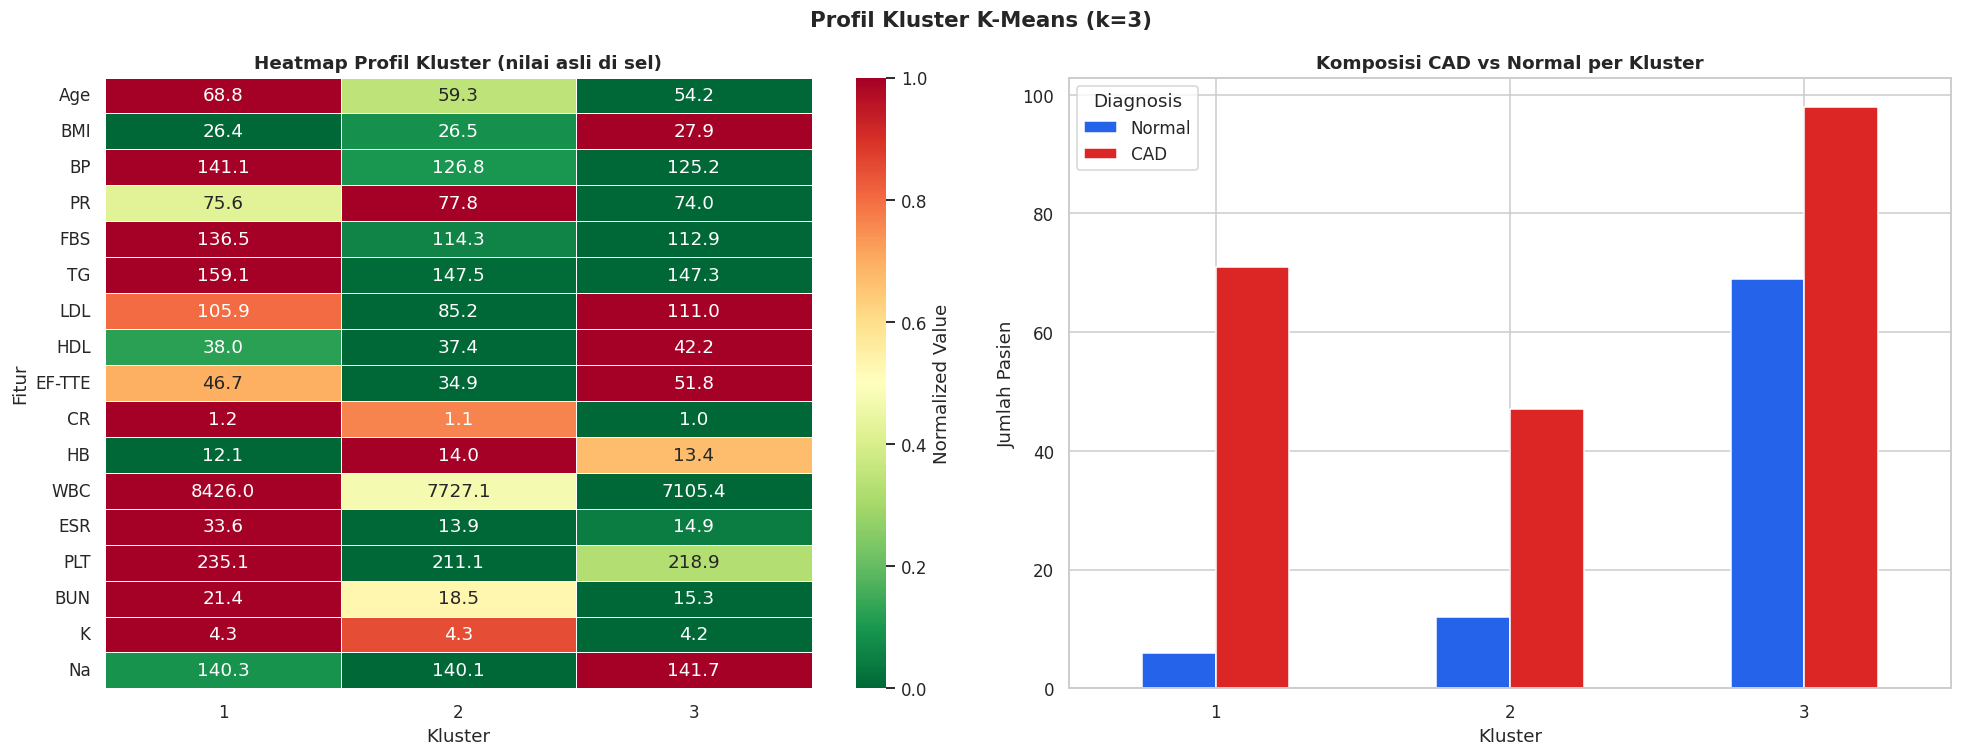

In [24]:
# Heatmap profil kluster
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Profil Kluster K-Means (k=3)', fontsize=14, fontweight='bold')

# Heatmap
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
sns.heatmap(profile_norm.T, annot=cluster_profile.T.values, fmt='.1f',
            cmap='RdYlGn_r', ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Normalized Value'})
axes[0].set_title('Heatmap Profil Kluster (nilai asli di sel)', fontweight='bold')
axes[0].set_xlabel('Kluster')
axes[0].set_ylabel('Fitur')

# Proporsi CAD
cath_prop = df_analyzed.groupby('Cluster')['Cath'].value_counts().unstack().fillna(0)
cath_prop.columns = ['Normal', 'CAD']
cath_prop.plot(kind='bar', ax=axes[1], color=COLORS, edgecolor='white', rot=0)
axes[1].set_xlabel('Kluster')
axes[1].set_ylabel('Jumlah Pasien')
axes[1].set_title('Komposisi CAD vs Normal per Kluster', fontweight='bold')
axes[1].legend(title='Diagnosis')

plt.tight_layout()
plt.savefig('fig12_cluster_profile.png', bbox_inches='tight')
plt.show()


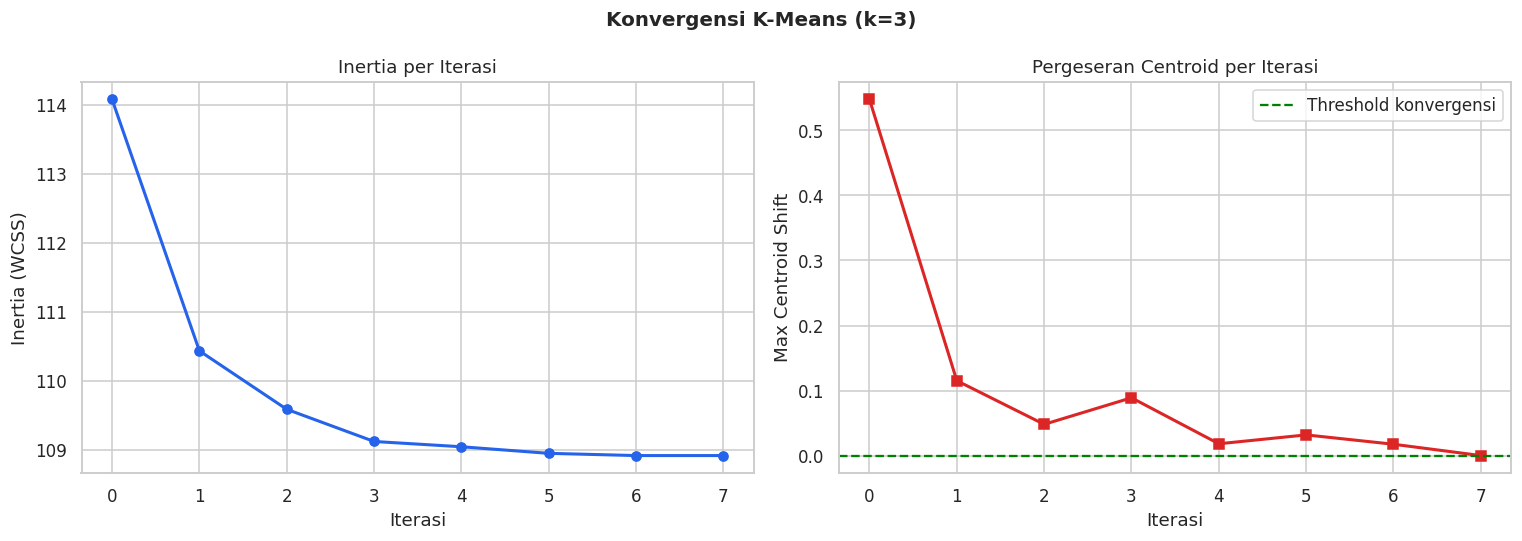

Konvergen pada iterasi ke-8


In [25]:
# Convergence history
km_conv = KMeansScratch(n_clusters=3, n_init=1, random_state=42)
km_conv.fit(X_arr)
hist_df = pd.DataFrame(km_conv.history_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Konvergensi K-Means (k=3)', fontsize=13, fontweight='bold')

axes[0].plot(hist_df['iter'], hist_df['inertia'], 'o-', color='#2563EB', lw=2)
axes[0].set_xlabel('Iterasi')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Inertia per Iterasi')

axes[1].plot(hist_df['iter'], hist_df['shift'], 's-', color='#DC2626', lw=2)
axes[1].axhline(1e-4, color='green', linestyle='--', label='Threshold konvergensi')
axes[1].set_xlabel('Iterasi')
axes[1].set_ylabel('Max Centroid Shift')
axes[1].set_title('Pergeseran Centroid per Iterasi')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig13_convergence.png', bbox_inches='tight')
plt.show()
print(f"Konvergen pada iterasi ke-{len(hist_df)}")


## 2.6 Evaluasi Kualitas Kluster

### Ringkasan Metrik per Skenario


EVALUASI KUALITAS KLUSTER
Skenario                    k      Inertia   Silhouette   Davies-Bouldin
----------------------------------------------------------------------
k=2 (Binary Risk)           2       114.05       0.1418           2.7950
k=3 (Multi-Risk)            3       107.32       0.1055           2.5448
k=4 (Fine-Grain)            4       102.07       0.0717           2.6073


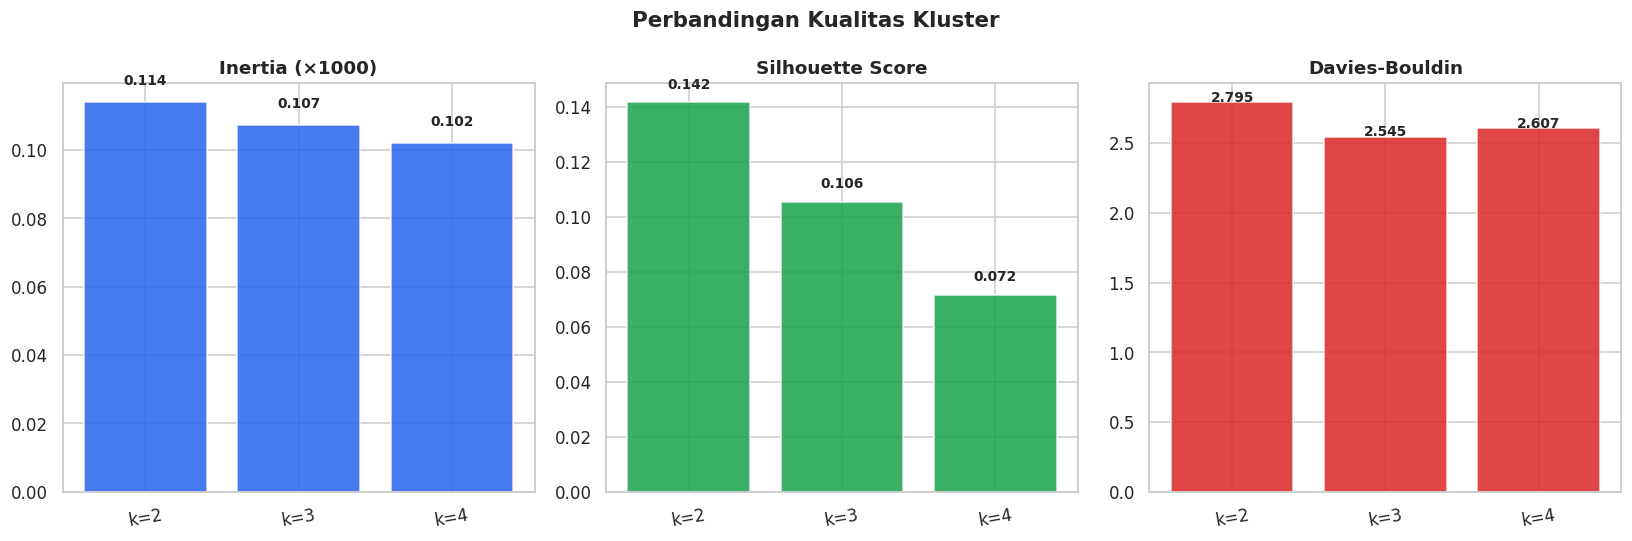

In [26]:
print("="*60)
print("EVALUASI KUALITAS KLUSTER")
print("="*60)
print(f"{'Skenario':<25} {'k':>3} {'Inertia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-"*70)
for name, res in results_km.items():
    print(f"{name:<25} {res['k']:>3} {res['inertia']:>12.2f} {res['silhouette']:>12.4f} {res['db']:>16.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perbandingan Kualitas Kluster', fontsize=14, fontweight='bold')
names = list(results_km.keys())
metrics_vals = {'Inertia (×1000)': [r['inertia']/1000 for r in results_km.values()],
                'Silhouette Score': [r['silhouette'] for r in results_km.values()],
                'Davies-Bouldin': [r['db'] for r in results_km.values()]}
metric_colors_list = ['#2563EB', '#16A34A', '#DC2626']
for ax, (m_name, vals), mc in zip(axes, metrics_vals.items(), metric_colors_list):
    bars = ax.bar(names, vals, color=mc, edgecolor='white', alpha=0.85)
    ax.set_title(m_name, fontweight='bold')
    ax.set_xticklabels([n.split('(')[0].strip() for n in names], rotation=10)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig14_cluster_eval.png', bbox_inches='tight')
plt.show()


## 2.7 Interpretasi Kluster (k=3)

| Kluster | Karakteristik Profil | Interpretasi Klinis |
|---------|---------------------|---------------------|
| **Kluster 1** | EF-TTE rendah, Region RWMA tinggi, FBS tinggi | Profil Risiko Tinggi — kemungkinan besar CAD |
| **Kluster 2** | EF-TTE normal, parameter metabolik sedang | Profil Risiko Menengah |
| **Kluster 3** | EF-TTE tinggi, semua parameter lebih baik | Profil Risiko Rendah — lebih banyak Normal |

---

## Kesimpulan Unsupervised Learning

1. **Jumlah kluster optimal k=3** berdasarkan kombinasi metode Elbow, Silhouette Score, dan Davies-Bouldin Index.

2. **K-Means berhasil membagi pasien** menjadi kelompok dengan profil risiko yang berbeda secara klinis, **tanpa menggunakan label Cath** sama sekali.

3. **Implementasi dari nol** (KMeansScratch) menghasilkan kluster yang konsisten dengan library, memvalidasi kebenaran implementasi manual.

4. **Temuan penting**: Kluster yang dibentuk secara natural berkorelasi dengan diagnosis CAD — menunjukkan bahwa kombinasi parameter klinis dan laboratorium memang memiliki pola yang dapat membedakan pasien CAD dan Normal.
